In [1]:
import numpy as np
from scipy.stats import chi2
from package import algorithm

# Binomial distribution

In [66]:
n = 10
num = 3
p = np.random.uniform(0,0.5,n)

In [146]:
n = 9000
num = 10
p = np.random.uniform(0,0.5,n)
#p=np.array([0.3,0.2,0.4]*int(n/3))
def test_binomial(p,num):
    Y = np.random.binomial(1,p)
    p[Y==0] = 1 - p[Y==0]
    chi,dof = algorithm.binomial_test(p,num)
    p_value = 1-chi2.cdf(chi,dof)
    return chi,p_value
test_binomial(p,num)

(7.948357978002016, 0.6338813632643685)

In [147]:
from joblib import Parallel,delayed
repeat_times = 1000
tasks = [delayed(test_binomial)(p,num) for _ in range(repeat_times)]
results = Parallel(n_jobs=6)(tasks)
results = np.array(results)
chi = results[:,0]

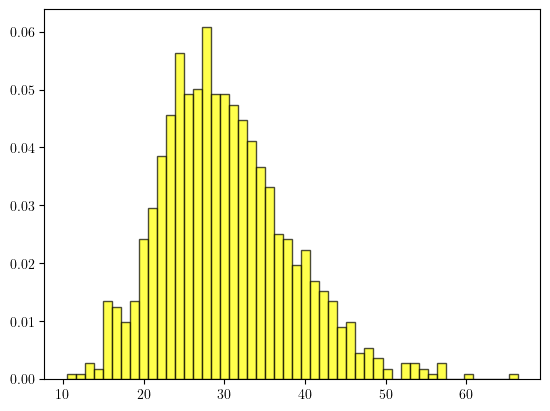

In [104]:
import matplotlib.pyplot as plt
plt.hist(chi,bins = 50,alpha=0.7, color='yellow', edgecolor='black',density = True)
plt.show()

In [148]:
np.mean(chi),np.std(chi)**2/2

(9.983778165194998, 9.481076225135073)

# with covariates

In [137]:
n = 1000
d = 3
v = np.array([i/d for i in range(d)])
X = np.random.normal(0,1,(n,d))
p = algorithm.s(X@v)
num = 15
file_name = 'inference test'
file_name_1 = 'DS'
file_name_2 = 'Dp-v'
sz=36

In [138]:
repeat_times = 10000
tasks = [delayed(test_statistics)(X,p,d,num) for _ in range(repeat_times)]
results = Parallel(n_jobs=5)(tasks)
results = np.array(results)

In [139]:
chi = results[:,0]
np.mean(chi),np.std(chi)**2/2

(14.056813867657803, 14.296710643499276)

Distribution of statistic

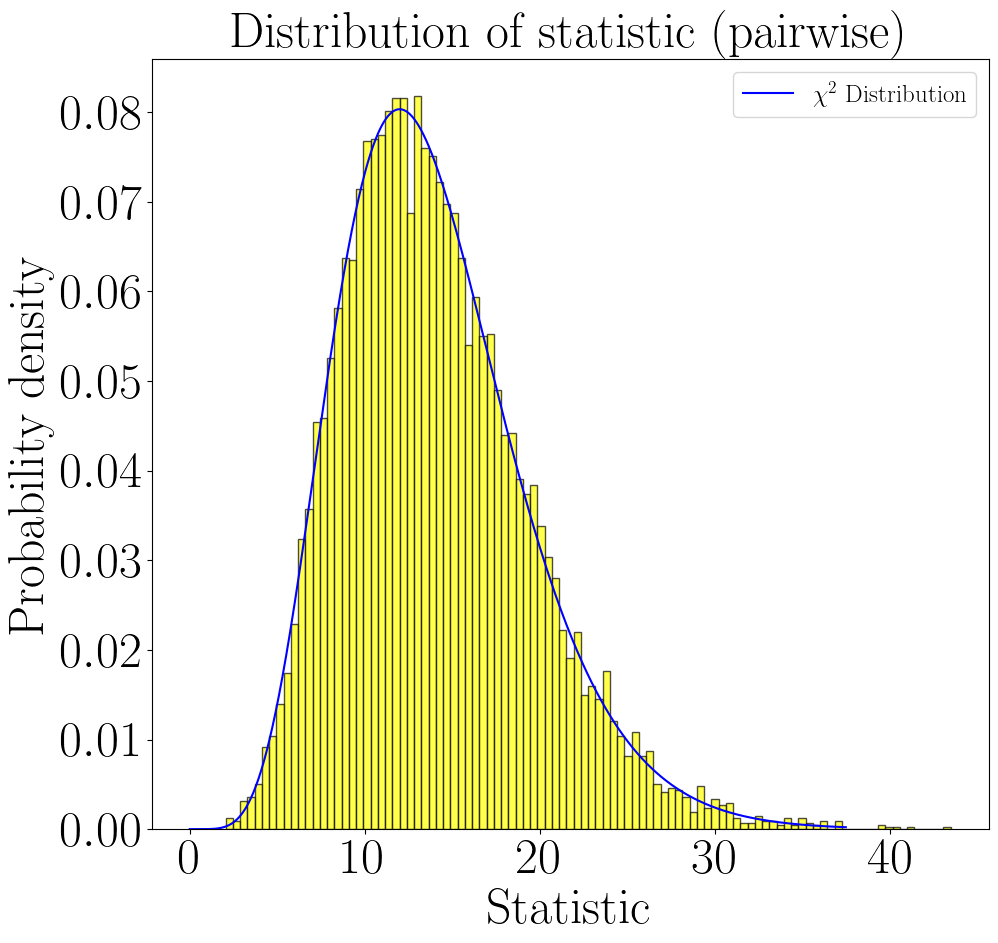

In [140]:
plt.figure(figsize=(10.8, 10))
x = np.linspace(0,2.5*num, 1000)
pdf = chi2.pdf(x, num-1)
plt.hist(results[:,0], bins=100, alpha=0.7, color='yellow', edgecolor='black',density = True)
plt.plot(x, pdf, label=r'$\chi^2$ Distribution', color='blue')
plt.title("Distribution of statistic (pairwise)",size =sz)
plt.xlabel('Statistic',size =sz)
plt.ylabel('Probability density',size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.legend(fontsize=sz/2)



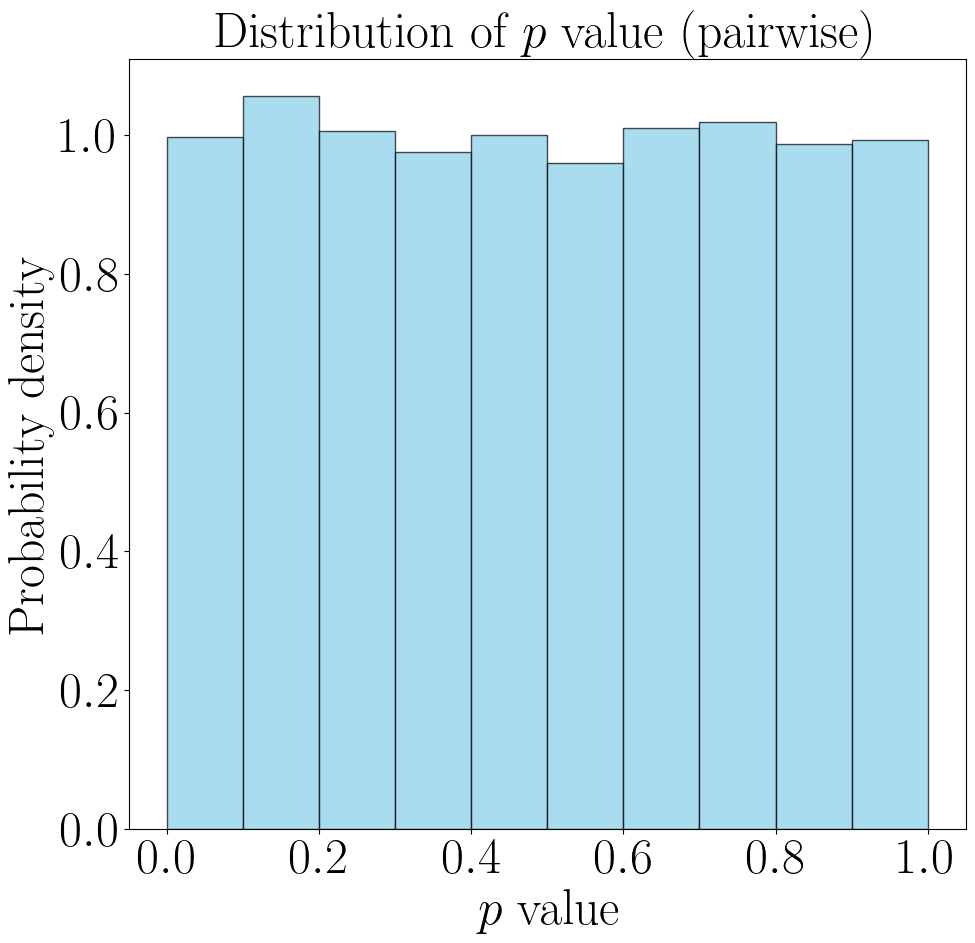

In [142]:
plt.figure(figsize=(10.8, 10))
plt.hist(results[:,1], bins=10, alpha=0.7, color='skyblue', edgecolor='black',density = True)
plt.title(r'Distribution of $p$ value (pairwise)',size=sz)
plt.xlabel(r'$p$ value',size=sz)
plt.ylabel('Probability density',size=sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.show()

# Multiple case